<p style="color: #E43F6F; font-size: 25px;text-align: center"><strong>TP 5: Analysing data</strong></p>

<span style="font-size: 18px;margin-bottom:0"><strong>Objectives:</strong></span>
<ul style="list-style: none">
  <li><span style="font-size:11px"> ▶</span> compute the Fourier transform of a signal,</li>
  <li><span style="font-size:11px"> ▶</span> generate random variables and measure their statistical properties,</li>
  <li><span style="font-size:11px"> ▶</span> compute and manipulate histograms,</li>
  <li><span style="font-size:11px"> ▶</span> use special functions and physical constants,</li>
  <li><span style="font-size:11px"> ▶</span> fit a set of data with a function,</li>
  <li><span style="font-size:11px"> ▶</span> read and write data (text or figures).</li>
</ul>

<span style="color: #E43F6F; font-size: 22px;"><strong>I. Fourier transform</strong></span>

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>1) Mathematical reminders</i></span>

You can also consult <strong>§IV.1.1</strong> of the lectures notes for another presentation.

<span style="color: #1BBAC6; font-size: 16px; margin-left: 4em;"><i>a) Definitions and conventions</i></span>

The Fourier transform generalizes the Fourier series to non-periodic functions. 

Let $s(t)$ be a time-dependent signal (real or complex) and $\tilde{s}(f)$ its Fourier transform: 
$$\displaystyle \tilde{s}(f)=\int_{-\infty}^{+\infty}\mathrm{d}t\,s(t)e^{-\mathrm{i}2\pi ft}.$$ 

The Fourier transform is invertible:

$$\displaystyle s(t)=\int_{-\infty}^{+\infty}\mathrm{d}f\,\tilde{s}(f)e^{\mathrm{i}2\pi ft}.$$

In practice, we can never measure the entire signal, we only have a <span style="color: #AB68B2;"><i>finite number of samples</i></span>. In other words, the value of $s(t)$ is only known at a finite number $N$ of points regularly spaced by $\delta t$ ($f_\mathrm{s}=1/\delta t$ is the sampling frequency). Thus, $s_k \equiv s(t_k)$, with $t_k \equiv k\delta t$, and $k = 0, \dots , N − 1$.

Trying to apply the Fourier transform to such a signal (by approximating the integral by a Riemann sum) would yield:
$$\tilde{s}(f)=\delta ts_0e^{-\mathrm{i}2\pi f(0\times \delta t)}+\delta ts_1e^{-\mathrm{i}2\pi f(\delta t)}+\dots \delta ts_k e^{-\mathrm{i}2\pi f(k\delta t)}+\dots +\delta ts_{N-1}e^{-\mathrm{i}2\pi f[(N-1)\delta t]}=\delta t\sum_{k=0}^{N-1}s_ke^{-\mathrm{i}2\pi k f \delta t}.$$
It is then obvious that $\tilde{s}(f+f_\mathrm{s})=\tilde{s}(f+1/\delta t)=\tilde{s}(f)$. Said differently, because of the time sampling, the Fourier transform is now periodic of period equal to the sampling frequency $f_\mathrm{s}$. Therefore, we can restrict ourselves to the frequency range $[-1/(2\delta t),\, 1/(2\delta t)[$. We note that the maximum frequency we can probe is half the sampling frequency. <strong> The total frequency range that you can probe is inversely proportional to the time discretization: the smaller the time discretization, the larger the frequency range!</strong>

Moreover, you cannot evaluate the above formula for any frequency $f\in\mathbb{R}$, because your signal is not infinitely long. Indeed, very loosely speaking, the Fourier transform $\tilde{s}(f)$ measures the amount of oscillation of the signal at frequency $f$. Because the total duration of the signal is $N\delta t$, you cannot detect oscillatory patterns of period larger than $N\delta t$, and consequently you cannot probe frequencies smaller than $1/(N\delta t)$ (except $f=0$ of course). In other words, <strong> the minimum strictly positive frequency you can probe (which corresponds to your frequency resolution) is inversely proportional to the total duration of the signal: the longer the signal, the thinner the frequency resolution!</strong> 

It turns out that you do not need to compute the $\tilde{s}(f)$ for all frequencies $f\in[-1/(2\delta t),\, -1/(N\delta t)]\times\lbrace0\rbrace\times[1/(N\delta t),\,1/(2\delta t)[$. You just need to evaluate the Fourier transform for $N$ discrete frequencies $$
f_n=\begin{cases}\displaystyle \frac{n}{N\delta t}\quad \text{for}\quad n=0,\dots,N/2-1,\\[0.8em]
\displaystyle \frac{n-N}{N\delta t}\quad \text{for}\quad n=N/2,..,N-1.
\end{cases}$$
The value of the Fourier transform for these $N$ discrete frequencies is then given by the <span style="color: #AB68B2;"><i>Discrete Fourier Transform</i></span> (DFT):
$$\tilde s_n=\sum_{k=0}^{N-1}s_ke^{-\mathrm{i}2\pi kn/N}.$$
(We have removed the multiplicative factor if you compare with the previous equation.)

The reason why we can restrict ourselves to these $N$ discrete frequencies is because the DFT is invertible, and that you can resconstruct the original signal from it:
$$s_k=\dfrac{1}{N}\sum_{n=0}^{N-1}\tilde s_ne^{\mathrm{i}2\pi kn/N}.$$
This formula looks very similar to the inverse Fourier transform for infinitely-long time-continuous signals.

<span style="color: #1BBAC6; font-size: 16px; margin-left: 4em;"><i>b) Spectrum of a signal</i></span>

Because the DFT is a complex number, one usually considers the <span style="color: #AB68B2;"><i>spectrum</i></span> $\vert\tilde s(f)\vert$ of a signal defined as the modulus of the DFT. The power spectrum is defined as the squared spectrum $\mathcal{S}(f)=\vert\tilde s(f)\vert^2$. Loosely speaking, the power spectrum is a strictly positive quantity which tells you the amount of "energy" in your signal at each frequency. This "energy" interpretation can be made more obvious thanks to the Plancherel-Parseval theorem:
$$\sum_{k=0}^{N-1}\vert s_k\vert^2=\frac{1}{N}\sum_{n=0}^{N-1}\vert\tilde s_n\vert^2.$$

<span style="color: #1BBAC6; font-size: 16px; margin-left: 4em;"><i>c) Aliasing</i></span>

As mentioned above, the time sampling of a continuous-time signal $s(t)$ results in a periodic Fourier transform of period $f_\mathrm{s}$ (the sampling frequency). 

Consequently, the DFT is a good approximate of the Fourier transform $\tilde{s}(f)$ of the original signal only if $\tilde{s}(f)$ is periodic of period $f_\mathrm{s}$. Obviously, this is verified if $\tilde{s}(f)$ vanishes for $\vert{f}\vert>f_\mathrm{s}/2$, or if the maximum frequency $f_\mathrm{max}$ (in absolute value) in the Fourier transform of $s(t)$ is such that $f_\mathrm{max}<f_\mathrm{s}/2$. <strong> We recover the Nyquist-Shannon sampling theorem, which tells you that if you want to reconstruct a signal, you have to choose the sampling frequency such that it is twice larger than the maximum frequency in the spectrum of the signal you want to reconstruct.</strong>

If the above condition is not verified, <i>i.e.,</i> if the Fourier transform presents frequencies larger than $f_\mathrm{s}/2$, then ghosts will appear in the DFT. This phenomenon is called <span style="color: #AB68B2;"><i>aliasing</i></span>. Frequencies $f>f_\mathrm{s}/2$ will "fold" back in the range $[-f_\mathrm{s}/2,\, f_\mathrm{s}/2[$ and will appear as ghosts of frequencies $\pm f+pf_\mathrm{s}$ with $p\in\mathbb{Z}$. In other words, frequencies above the Nyquist frequency pollute the spectrum obtained by DFT at lower frequencies, and the inverse DFT no longer allows the original discrete signal to be recovered.

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>2) Calculation with NumPy</i></span>

<span style="color: #1BBAC6; font-size: 16px; margin-left: 4em;"><i>a) The algorithm</i></span>

The algorithm used to compute DFTs in Python is called <span style="color: #AB68B2;"><i>the Fast Fourier Transform (FFT)</i></span> algorithm. Because this algorithm is heavily used to compute DFTs, people often talk about FFTs rather than DFTs.

<span style="color: #1BBAC6; font-size: 16px; margin-left: 4em;"><i>b) Implementation</i></span>

The calculation of the DFT of a signal is done via the function <tt>fft</tt> of the <span style="color: #AB68B2;"><i>fft module in the NumPy package</i></span>. The frequencies at which the DFT is calculated can be returned by the function <tt>fftfreq</tt>. The module fft has other functions which will not be discussed in this notebook, but you can consult the documentation for more information: https://numpy.org/doc/stable/reference/routines.fft.html
<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="programming.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align: center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> Run the code below to understand how to compute Discrete Fourier Transforms in Python. Add appropriate comments when required.</strong></span>
    </td>
  </tr>
</table>

[ 0.96592583  0.62932039  0.05233596 -0.54463904 -0.93358043 -0.96592583
 -0.62932039 -0.05233596  0.54463904  0.93358043  0.96592583  0.62932039
  0.05233596 -0.54463904 -0.93358043 -0.96592583 -0.62932039 -0.05233596
  0.54463904  0.93358043]
[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5 -5.  -4.5 -4.  -3.5
 -3.  -2.5 -2.  -1.5 -1.  -0.5]
[-6.93889390e-16+0.00000000e+00j  6.30771086e-16+5.62908975e-16j
  9.65925826e+00+2.58819045e+00j -9.29622061e-17+1.97389652e-16j
 -1.83391937e-16-2.94566890e-16j -1.31145095e-15-2.52575738e-15j
  3.55271368e-15+0.00000000e+00j  1.36329264e-15+7.72283060e-16j
  5.30336632e-16+9.48825297e-16j -1.14476208e-15+2.37740960e-15j
 -2.55351296e-15+2.22044605e-16j -1.14476208e-15-2.37740960e-15j
  5.30336632e-16-9.48825297e-16j  1.36329264e-15-7.72283060e-16j
  1.88737914e-15+2.22044605e-16j -1.31145095e-15+2.52575738e-15j
 -1.83391937e-16+2.94566890e-16j -9.29622061e-17-1.97389652e-16j
  9.65925826e+00-2.58819045e+00j  6.30771086e-16-5.62908975e-16j]


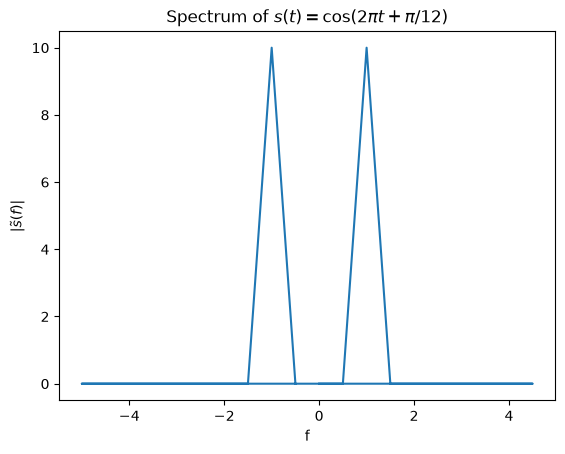

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
dt = 0.1  # Time interval between two samples.
fc = 1. / dt  # Sampling frequency
f0 = 1.  # Frequency of the signal.
T0 = 1. / f0  # Period of the signal
t = np.arange(0., 2 * T0, dt)  # Time axis
s = np.cos(2. * np.pi * f0 * t + np.pi / 12.)  # Signal
print(s)

tilde_s = np.fft.fft(s)  # returns every computed value of fft(s)
freq = np.fft.fftfreq(s.size, dt)  # return the frequency of each of these tildes
print(freq)  # both array of s.size
print(tilde_s)  # both array of s.size ^

plt.figure()
plt.plot(freq, np.abs(tilde_s))  # Plot the magnitude of the FFT
plt.xlabel('f')
plt.ylabel(r'$\vert\tilde{s}(f)\vert$')
plt.title(r'Spectrum of $s(t)=\cos(2\pi t + \pi/12)$')
plt.show()

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="sharing.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px;">
      <span style="color: #CF7EA0; font-size:16px;"><strong> What is the value of the Discrete Fourier Transform for a cosine (or sine) function?</strong></span>
    </td>
  </tr>
</table>

[-5.  -4.5 -4.  -3.5 -3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5
  2.   2.5  3.   3.5  4.   4.5]
[-2.55351296e-15+2.22044605e-16j -1.14476208e-15-2.37740960e-15j
  5.30336632e-16-9.48825297e-16j  1.36329264e-15-7.72283060e-16j
  1.88737914e-15+2.22044605e-16j -1.31145095e-15+2.52575738e-15j
 -1.83391937e-16+2.94566890e-16j -9.29622061e-17-1.97389652e-16j
  9.65925826e+00-2.58819045e+00j  6.30771086e-16-5.62908975e-16j
 -6.93889390e-16+0.00000000e+00j  6.30771086e-16+5.62908975e-16j
  9.65925826e+00+2.58819045e+00j -9.29622061e-17+1.97389652e-16j
 -1.83391937e-16-2.94566890e-16j -1.31145095e-15-2.52575738e-15j
  3.55271368e-15+0.00000000e+00j  1.36329264e-15+7.72283060e-16j
  5.30336632e-16+9.48825297e-16j -1.14476208e-15+2.37740960e-15j]


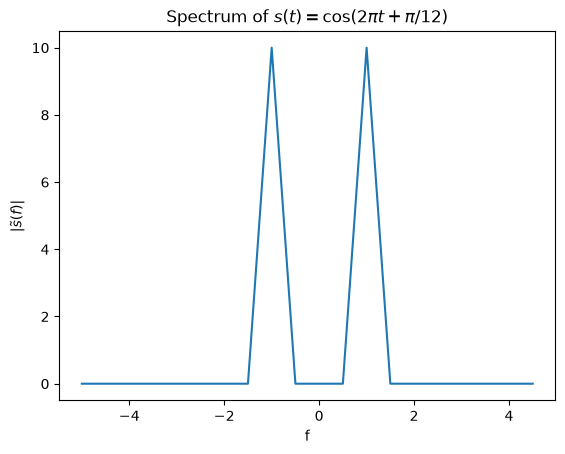

In [ ]:
tilde_s = np.fft.fftshift(np.fft.fft(s))
freq = np.fft.fftshift(np.fft.fftfreq(s.size, dt))
print(freq)  # shift the 0 frequency at the center, shouldnt change a thing considering the previous one
print(tilde_s)

plt.figure()
plt.plot(freq, np.abs(tilde_s))
plt.xlabel('f')
plt.ylabel(r'$\vert\tilde{s}(f)\vert$')
plt.title(r'Spectrum of $s(t)=\cos(2\pi t + \pi/12)$')
plt.show()

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="sharing.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px;">
      <span style="color: #CF7EA0; font-size:16px;"><strong> What is the interest of the function <tt>fftshift</tt>?</strong></span>
    </td>
  </tr>
</table>

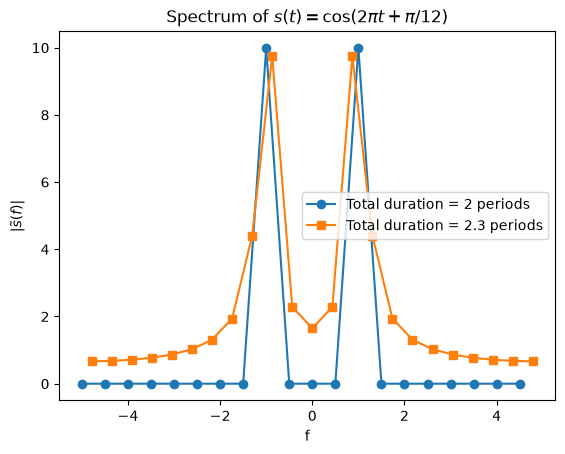

In [ ]:
dt = 0.1
fc = 1. / dt
f0 = 1.
T0 = 1. / f0
t1 = np.arange(0., 2 * T0, dt)  # first time range
s1 = np.cos(2. * np.pi * f0 * t1 + np.pi / 12.)
t2 = np.arange(0., 2.3 * T0, dt)  # second time range, slightly wider, but same signal, we get more detailed frequencies since we work on a longer signal
s2 = np.cos(2. * np.pi * f0 * t2 + np.pi / 12.)

tilde_s1 = np.fft.fftshift(np.fft.fft(s1))
freq1 = np.fft.fftshift(np.fft.fftfreq(s1.size, dt))
tilde_s2 = np.fft.fftshift(np.fft.fft(s2))
freq2 = np.fft.fftshift(np.fft.fftfreq(s2.size, dt))

plt.figure()
plt.plot(freq1, np.abs(tilde_s1), '-o', label='Total duration = 2 periods')
plt.plot(freq2, np.abs(tilde_s2), '-s', label='Total duration = 2.3 periods')
plt.xlabel('f')
plt.ylabel(r'$\vert\tilde{s}(f)\vert$')
plt.title(r'Spectrum of $s(t)=\cos(2\pi t + \pi/12)$')
plt.legend()
plt.show()

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="sharing.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align:center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> What is the effect on the Discrete Fourier Transform of sampling a periodic function on a total duration which is not an integer multiple of its period?</strong></span>
    </td>
  </tr>
</table>

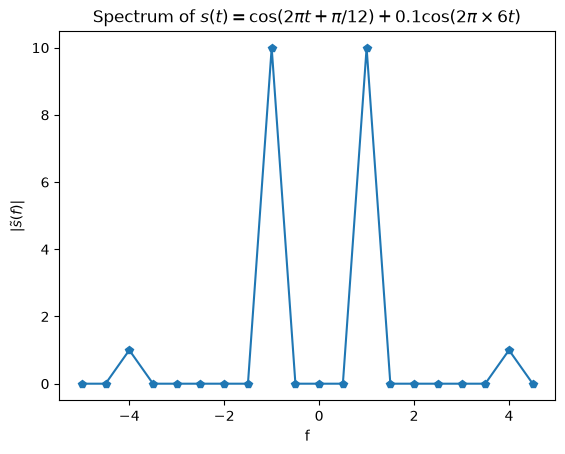

In [5]:
dt = 0.1
fc = 1. / dt
f0 = 1.
f1 = 6.
T0 = 1. / f0
T1 = 1. / f1
t = np.arange(0., 2 * T0, dt)
s = np.cos(2. * np.pi * f0 * t + np.pi / 12.) + 0.1 * np.cos(2. * np.pi * f1 * t)

tilde_s = np.fft.fftshift(np.fft.fft(s))
freq = np.fft.fftshift(np.fft.fftfreq(s.size, dt))

plt.figure()
plt.plot(freq, np.abs(tilde_s), '-p')
plt.xlabel('f')
plt.ylabel(r'$\vert\tilde{s}(f)\vert$')
plt.title(r'Spectrum of $s(t)=\cos(2\pi t + \pi/12) + 0.1\cos(2\pi\times 6t)$')
plt.show()

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="sharing.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align:center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> Can you rationalize the output of the above cell?</strong></span>
    </td>
  </tr>
</table>

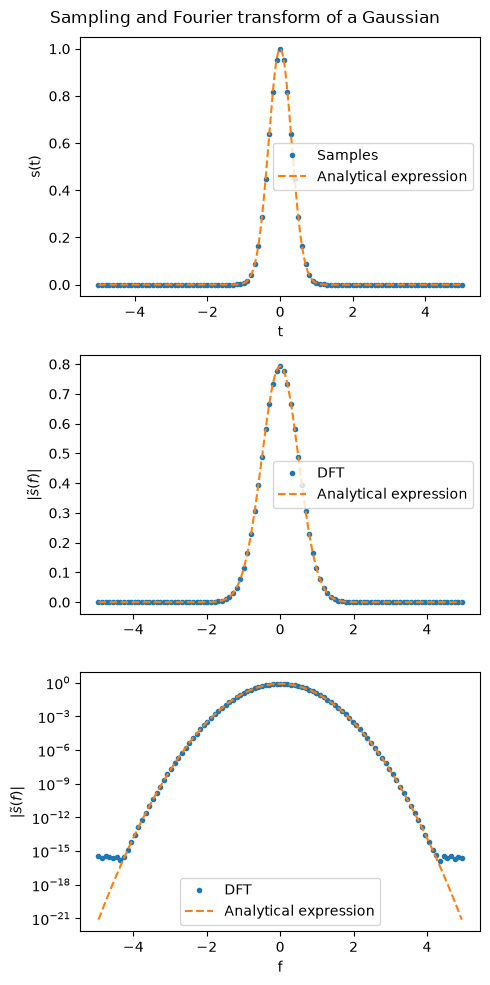

In [ ]:
alpha = 5.
t = np.linspace(-5., 5., 101)
s = np.exp(-alpha * t ** 2)  # gaussian plot
tt = np.linspace(t[0], t[-1], 1001)
ss = np.exp(-alpha * tt ** 2)

tilde_s = np.fft.fftshift(np.fft.fft(s))
tilde_s *= (t[1] - t[0])  # conversion from sum to integral approximation ?
freq = np.fft.fftshift(np.fft.fftfreq(t.size, t[1] - t[0]))

ff = np.linspace(freq[0], freq[-1], 1001)  # linspace from first to last frequency, same size as tt
tilde_ss = np.sqrt(np.pi / alpha) * np.exp(- ff ** 2 * np.pi ** 2 / alpha)  # Analytical result for the Fourier transform of the Gaussian.

plt.figure(figsize=(5, 10))  # figsize allows you to give the width and height of the figure in inches (1 inch = 2.54 cm).
plt.subplot(3, 1, 1)
plt.plot(t, s, '.', label='Samples')
plt.plot(tt, ss, '--', label='Analytical expression')
plt.xlabel('t')
plt.ylabel('s(t)')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(freq, np.absolute(tilde_s), '.', label='DFT')
plt.plot(ff, np.absolute(tilde_ss), '--', label='Analytical expression')
plt.legend()
plt.ylabel(r'$\vert\tilde{s}(f)\vert$')
plt.subplot(3, 1, 3)
plt.plot(freq, np.absolute(tilde_s), '.', label='DFT')
plt.plot(ff, np.absolute(tilde_ss), '--', label='Analytical expression')
plt.yscale('log')
plt.legend()
plt.ylabel(r'$\vert\tilde{s}(f)\vert$')
plt.xlabel('f')
plt.suptitle('Sampling and Fourier transform of a Gaussian')
plt.tight_layout()
plt.show()

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="sharing.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align:center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> How does the result change with the number of samples?</strong></span>
    </td>
  </tr>
</table>

<span style="color: #E43F6F; font-size: 22px;"><strong>II. Random numbers</strong></span>

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>1) Generate random numbers</i></span>

The NumPy package has a module <span style="color: #AB68B2;"><i>random</i></span> which allows you to draw random numbers from different probability distributions. You can look at the documentation for the full list of distributions available: https://numpy.org/doc/stable/reference/random/generator.html

To be more precise, all the functions of this module are pseudo-random number generators because they create deterministic arrays of samples which follow approximately the target probability distribution. These arrays are created from an integer, called <span style="color: #AB68B2;"><i>a seed</i></span>.

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="programming.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align: center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> Run the code below which illustrates how to draw random numbers with a target distribution in Python. Add appropriate comments when required.</strong></span>
    </td>
  </tr>
</table>

[0.96321156 0.91392508 0.71937626 0.44060945 0.52927181 0.42688377
 0.91723409 0.86075095 0.42054209 0.45515585]


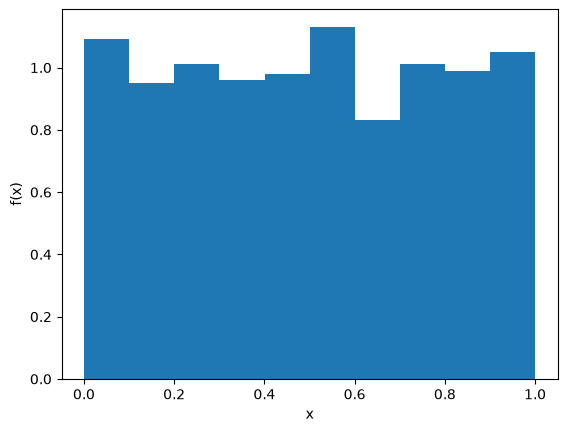

In [ ]:
x = np.random.random(1000)  # 1D array of 1000 random values between 0 and 1 (1 excluded)
print(x[:10])
plt.hist(x, density=True)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

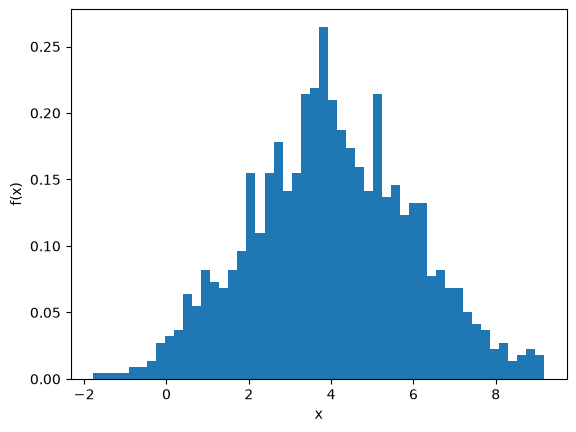

In [ ]:
x = np.random.normal(4., 2., 1000)  # normal distrib centered around 4., standard dev of 2., 1000 samples
plt.hist(x, bins=50, density=True)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

In [ ]:
np.random.seed(19680801)  # Impose the seed value to 19680801.
x = np.random.random(10)
print(x)
y = np.random.random(10)
print(y)
np.random.seed(19680801)
z = np.random.random(10)  # deterministic, not really random since a computer cannot do random
print(z)

[0.7003673  0.74275081 0.70928001 0.56674552 0.97778533 0.70633485
 0.24791576 0.15788335 0.69769852 0.71995667]
[0.25774443 0.34154678 0.96876117 0.6945071  0.46638326 0.7028127
 0.51178587 0.92874137 0.7397693  0.62243903]
[0.7003673  0.74275081 0.70928001 0.56674552 0.97778533 0.70633485
 0.24791576 0.15788335 0.69769852 0.71995667]


<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>2) Compute statistical properties</i></span>

When we work with random numbers, we are often interested in their statistical properties, like <span style="color: #AB68B2;"><i>their distribution</i></span>, or more reasonably, their <span style="color: #AB68B2;"><i>first cumulants</i></span>. Some functions are present in NumPy (see TP3), while others can be found in the module <span style="color: #AB68B2;"><i>stats of the SciPy package</i></span>. (The module stats also has functions to generate random numbers but they are not covered in these lectures.) The SciPy package heavily relies on the NumPy package and thus allows you to manipulate arrays. For more details about the functions available in the stats module, you can look at the documentation: https://docs.scipy.org/doc/scipy/reference/stats.html

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="programming.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align: center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> Run the code below which illustrates how to compute the statistical properties of random variables in Python. Add appropriate comments when required.</strong></span>
    </td>
  </tr>
</table>

In [ ]:
x = np.random.uniform(-1, 1, 1000)  # uniform distribution
print(np.mean(x))  # should be near 0
print(np.var(x))  # should return the variance
print(np.std(x))  # should be near 0.5
print(np.median(x))  # should be near 0

0.02872494264848393
0.33616512070859494
0.5797974824959099
0.04152439104261407


(array([636, 241,  79,  26,  10,   4,   3,   0,   0,   1]), array([6.18199023e-04, 9.79791095e-01, 1.95896399e+00, 2.93813689e+00,
       3.91730978e+00, 4.89648268e+00, 5.87565558e+00, 6.85482847e+00,
       7.83400137e+00, 8.81317426e+00, 9.79234716e+00]))


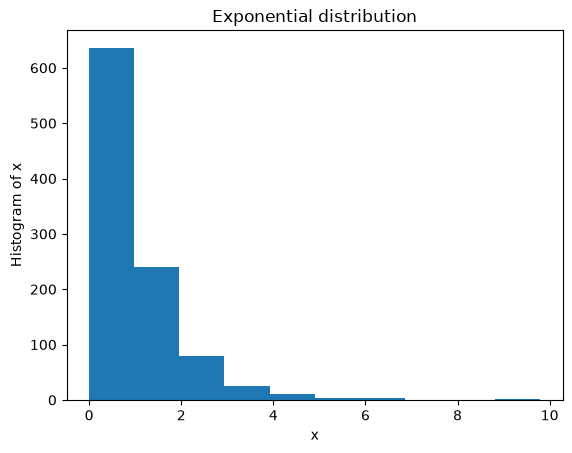

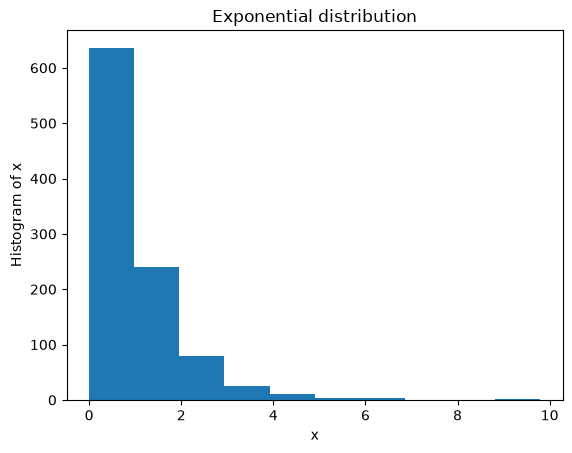

In [ ]:
x = np.random.exponential(1., 1000)  # exponential distribution of 1000 samples and of scale 1
print(np.histogram(x))  # print the corresponding histogram data returned by np.hist

histo, bin_edges = np.histogram(x)
plt.figure()
plt.bar(bin_edges[:-1], histo, bin_edges[1] - bin_edges[0], align='edge')  # manually plot the histograom instead of using plt.hist
plt.xlabel('x')
plt.ylabel('Histogram of x')
plt.title('Exponential distribution')
plt.show()

plt.figure()
plt.hist(x)
plt.xlabel('x')
plt.ylabel('Histogram of x')
plt.title('Exponential distribution')
plt.show()

In [ ]:
x = np.random.random(100)
y = np.random.random(100)
print(np.cov(x, y))  # covariance of x, y, since they were 1D array it should return, off diagonal terms should be identical and close to 0, while diagonal term are the variance (cov(x,x) = var(x))
print(np.var(x), np.mean((x - np.mean(x)) * (y - np.mean(y))), np.var(y))

print(np.corrcoef(x, y))  # COMMENT REQUIRED
print(np.mean((x - np.mean(x)) * (y - np.mean(y))) / np.sqrt(np.var(x) * np.var(y)))

[[0.07602738 0.01773915]
 [0.01773915 0.08708275]]
0.07526710170804016 0.0175617540824993 0.08621192364981844
[[1.         0.21801262]
 [0.21801262 1.        ]]
0.21801261644903142


In [ ]:
import scipy.stats as stats
x = np.random.normal(size=1000)  # 1000 bins of normal dsitrib
print(stats.skew(x))  # compute the skewness (is it more to the right or left), for a normal distrib, it should be around 0
print(stats.kurtosis(x))  # measure the tailedness of a distribution, how much of the distribution is in the tails, negative value means lighter tails

0.03419108984091345
-0.24154651663955473


<span style="color: #E43F6F; font-size: 22px;"><strong>III. Special functions and physical constants</strong></span>

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>1) Special functions</i></span>

The <span style="color: #AB68B2;"><i>module Special of the package SciPy</i></span> presents many special functions that you might need one day (in particular to model experimental or numerical data). Below are listed few examples but the full list is given in the online documentation: https://docs.scipy.org/doc/scipy/reference/special.html

<ul style="list-style: none">
  <li><span style="font-size:11px"> ▶</span> Airy functions, their derivatives and their zeros (very useful in Optics);</li>
  <li><span style="font-size:11px"> ▶</span> Bessel, Hankel functions, their derivatives, integrals and their zeros (very useful in the context of wave propagation or diffraction involving circular or cylindrical geometries);</li>
  <li><span style="font-size:11px"> ▶</span> Gamma function and other related functions (very useful in Statistical Physics or in High-Energy Physics);</li>
  <li><span style="font-size:11px"> ▶</span> Error function and other related functions (very useful in Statistical Physics);</li>
  <li><span style="font-size:11px"> ▶</span> Fresnel integrals (very useful in Optics);</li>
  <li><span style="font-size:11px"> ▶</span> Many polynomial functions, <i>e.g.,</i> Legendre, Laguerre, Hermite polynomials (very useful in Quantum Mechanics);</li>
  <li><span style="font-size:11px"> ▶</span> etc.</li>
</ul>

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="programming.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align: center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> Run the code below which illustrates the use of several special functions in Python. Add appropriate comments when required.</strong></span>
    </td>
  </tr>
</table>

In [ ]:
import scipy.special as spe
x = np.arange(1, 10)
print(x)
print(spe.gamma(x))  # gamma function
y = np.ones_like(x, dtype=int)
for i in range(1, x.size):
    y[i] = np.prod(x[:i])
print(y)  # product over the whole array

[1 2 3 4 5 6 7 8 9]
[1.000e+00 1.000e+00 2.000e+00 6.000e+00 2.400e+01 1.200e+02 7.200e+02
 5.040e+03 4.032e+04]
[    1     1     2     6    24   120   720  5040 40320]


<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>2) Physical constants</i></span>

The <span style="color: #AB68B2;"><i>module Constants of the package SciPy</i></span> presents physical and mathematical constants, along with units that you might need one day (again to model experimental or numerical data). Below are listed few examples but the full list is given in the online documentation: https://docs.scipy.org/doc/scipy/reference/constants.html

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="programming.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align: center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> Run the code below which illustrates the use of several physical constants in Python. Add appropriate comments when required.</strong></span>
    </td>
  </tr>
</table>

In [15]:
import scipy.constants as constant
print(constant.pi, np.pi)
print(constant.golden, 0.5 * (1. + np.sqrt(5.)))  # Golden number.

print(constant.Avogadro)  # COMMENT REQUIRED
print(constant.Boltzmann)  # COMMENT REQUIRED
print(constant.Planck)  # COMMENT REQUIRED

3.141592653589793 3.141592653589793
1.618033988749895 1.618033988749895
6.02214076e+23
1.380649e-23
6.62607015e-34


In [16]:
print(constant.fermi)  # COMMENT REQUIRED
print(constant.angstrom)  # COMMENT REQUIRED
print(constant.light_year, constant.c * 3600 * 24 * 365.25)  # COMMENT REQUIRED

1e-15
1e-10
9460730472580800.0 9460730472580800.0


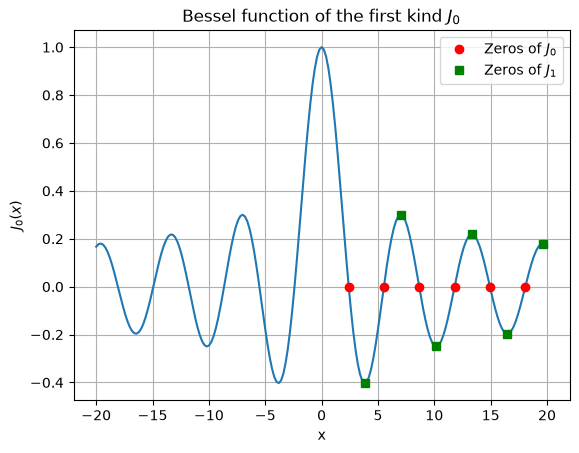

In [17]:
x = np.linspace(-20, 20, 201)
zeros_j0 = spe.jn_zeros(0, 6)  # Useful if you are interested in the vibrational modes in a cylindrical waveguide.
zeros_j1 = spe.jn_zeros(1, 6)
plt.figure()
plt.plot(x, spe.j0(x))
plt.plot(zeros_j0, np.zeros(zeros_j0.size), 'or', label=r'Zeros of $J_0$')
plt.plot(zeros_j1, spe.j0(zeros_j1), 'sg', label=r'Zeros of $J_1$')  # -J1 is the derivative of J0.
plt.xlabel('x')
plt.ylabel(r'$J_0(x)$')
plt.title(r'Bessel function of the first kind $J_0$')
plt.grid()
plt.legend()
plt.show()

3424821031470642.0
9.1093837139e-31
1.0545718176461565e-34


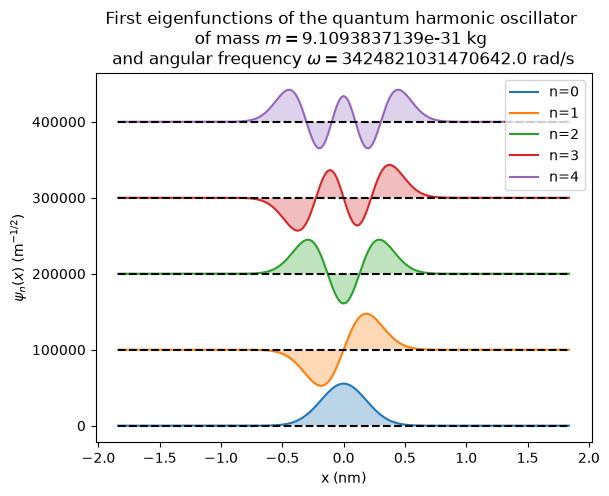

In [18]:
omega = 2. * np.pi * constant.nu2lambda(550 * constant.nano)  # COMMENT REQUIRED
print(omega)
m = constant.electron_mass  # COMMENT REQUIRED
print(m)
hbar = constant.hbar  # COMMENT REQUIRED
print(hbar)


def eigenfunction_harmonic_oscillator(x, n):  # Return the value of the nth eigenfunction of the quantum harmonic oscillator at position x.
    return 1. / np.sqrt(2 ** n * spe.gamma(n + 1)) * \
           (m * omega / (np.pi * hbar)) ** 0.25 * \
           np.exp(- m * omega * x ** 2 / (2. * hbar)) * \
           spe.eval_hermite(n, np.sqrt(m * omega / hbar) * x)


plt.figure()
x = np.linspace(-10. * np.sqrt(hbar / (m * omega)), 10 * np.sqrt(hbar / (m * omega)), 201)  # COMMENT REQUIRED
shift = 1e5
for i in range(5):
    plt.plot(x * 1e9, eigenfunction_harmonic_oscillator(x, i) + i * shift, label='n=' + str(i))  # COMMENT REQUIRED
    plt.plot(x * 1e9, np.full_like(x, i * shift), '--k')  # COMMENT REQUIRED
    plt.fill_between(x * 1e9, i * shift, eigenfunction_harmonic_oscillator(x, i) + i * shift, alpha=0.3)  # COMMENT REQUIRED
plt.xlabel('x (nm)')
plt.ylabel(r'$\psi_n(x)$ (m$^{-1/2}$)')
plt.legend()
plt.title('First eigenfunctions of the quantum harmonic oscillator \n' +   # \n to go to line but does not work with r before the string.
          r'of mass $m=$' + str(m) + ' kg \n' +
          r'and angular frequency $\omega=$' + str(omega) + ' rad/s')
plt.show()

<span style="color: #E43F6F; font-size: 22px;"><strong>IV. Curve fitting</strong></span>

When you perform an experiment or a simulation, you may have the objective of validating a theoretical model. Said differently, you may want to confront the results from your experiment or simulation to the analytical prediction of the model. Usually, this comparison is done by analyzing if the data points (your results) follow a curve (the analytical prediction). The latter involves several adjustable parameters which are usually unknown. The value of these parameters may also be interesting in order to characterize your system.

As a result, the procedure of trying to overimpose data points with a model, called <span style="color: #AB68B2;"><i>curve fitting</i></span> is crucial. The <span style="color: #AB68B2;"><i>module Optimize of the package SciPy</i></span> presents several functions for curve fitting. In these lectures, we only focus on the function <tt>curve_fit</tt>, but the others (<tt>least_squares</tt> in particular which gives more freedom) are described in the online documentation: https://docs.scipy.org/doc/scipy/reference/optimize.html

We illustrate the procedure on the following example. An experiment consists in measuring the magnetic field in the center of a coil at a constant current intensity $I$. The laws of magnetostatics give that the magnetic field equals
$$B=\dfrac{\mu_0 NI}{\sqrt{D^2+\ell^2}},$$ with $D$ the diameter of the coil, $\ell$ its length, and $N$ the number of turns. You are given the results of $B$ (with their uncertainties) measured thanks to a teslameter, and of $I$ (with their uncertainties) measured thanks to an amperemeter. In the experiment, the coil had a diameter $D=(9.2\pm0.2)\,\mathrm{cm}$, a length $\ell=(41.0\pm0.2)\,\mathrm{cm}$ and a number of turns $N=120\pm1$. The function $B(I)$ is therefore expected to be a linear function, of slope $a=\mu_0N/\sqrt{\ell^2+D^2}$, with an expected value $a_\mathrm{th}=(0.359\pm0.005)\, \mathrm{mT/A}$, where the uncertainty is obtained via propagation of uncertainties
$$\frac{u(a_\mathrm{th})}{a_\mathrm{th}}=\frac{u(N)}{N}+\frac{\ell u(\ell)+Du(D)}{\ell^2+D^2}.$$

The objective is to validate the model obtained from the law of magnetostatics theory, which involves approximations or assumptions that may not be verified experimentally (the magnetic field is not precisely measured at the center of the coil, there are residual magnetic fields in the room, etc.).

<table style="border: none;">
  <tr>
    <td style="vertical-align: middle;">
      <img src="programming.png" width="40">
    </td>
    <td style="vertical-align: middle; padding-left: 10px; text-align: center">
      <span style="color: #CF7EA0; font-size:16px;"><strong> Run the code below to understand how to fit a curve to a set of data in Python. Add appropriate comments when required.</strong></span>
    </td>
  </tr>
</table>

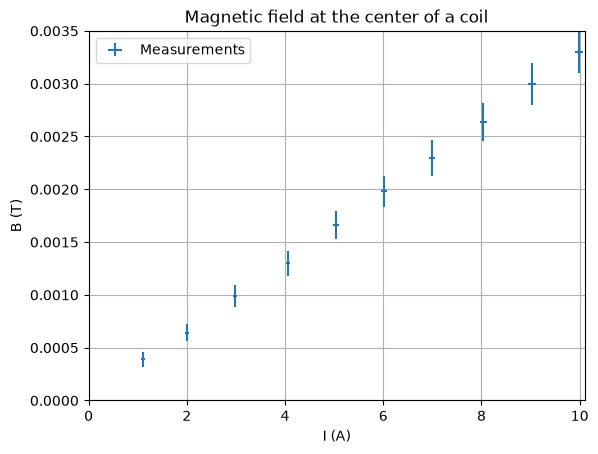

In [ ]:
I = np.array([1.10, 2.00, 2.99, 4.06, 5.03, 6.02, 7.00, 8.04, 9.02, 9.99])  # Intensity of the current in A.
uI = np.array([0.04, 0.04, 0.04, 0.05, 0.06, 0.06, 0.06, 0.07, 0.08, 0.08])  # Uncertainty on the intensity in A.
B = np.array([0.39, 0.64, 0.99, 1.30, 1.66, 1.98, 2.30, 2.64, 3.0, 3.3])  # Magnetic field in mT.
uB = np.array([0.07, 0.08, 0.10, 0.12, 0.13, 0.15, 0.17, 0.18, 0.2, 0.2])  # Uncertainty on the magnetic field in mT.
B *= 1e-3  # We convert the magnetic field in T (safer to avoid conversion mistakes).
uB *= 1e-3  # We convert the uncertainty on the magnetic field in T (safer to avoid conversion mistakes).
D = 9.2e-2  # Diameter of the coil in m.
uD = 0.2e-2  # Uncertainty on the diameter in m.
l = 0.410  # Lenght of the coil in m.
ul = 0.2e-2  # Uncertainty on the length in m.
N = 120  # Number of turns.
uN = 1  # Uncertainty on the number of turns.

plt.figure()
plt.errorbar(I, B, uB, uI, linestyle='', label='Measurements')  # fit error bar requiring 2 arrays of data and their respective uncertainty
plt.xlabel('I (A)')
plt.ylabel('B (T)')
plt.title('Magnetic field at the center of a coil')
plt.legend()
plt.axis([0, 10.1, 0, 3.5e-3])
plt.grid()
plt.show()

(array([ 3.30565580e-04, -6.37483293e-06]), array([[ 5.30530576e-12, -2.93117828e-11],
       [-2.93117828e-11,  2.05302607e-10]]))


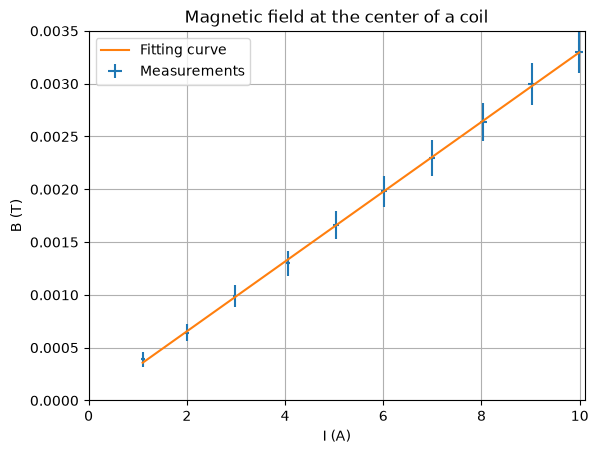

In [ ]:
# Fitting procedure without considering the errorbars and without help to guess the adjustable parameters.
import scipy.optimize as opt


def affine_function(x, a, b):  # we define what is the function we are looking for
    return a * x + b


print(opt.curve_fit(affine_function, I, B))  # it returns the optimal values for both parameters a and b so that they fit I/B
popt, pcov = opt.curve_fit(affine_function, I, B) # also returns the covariance (so that we can compute the relative error)
a = popt[0]
b = popt[1]

plt.figure()
plt.errorbar(I, B, uB, uI, linestyle='', label='Measurements')
plt.plot(I, affine_function(I, a, b), label='Fitting curve')
plt.xlabel('I (A)')
plt.ylabel('B (T)')
plt.title('Magnetic field at the center of a coil')
plt.legend()
plt.axis([0, 10.1, 0, 3.5e-3])
plt.grid()
plt.show()

a= 0.00033056557786609943 T/A,   a_th= 0.00035887237635885553 T/A
b= -6.374817221322218e-06 T,   b_th= 0 T


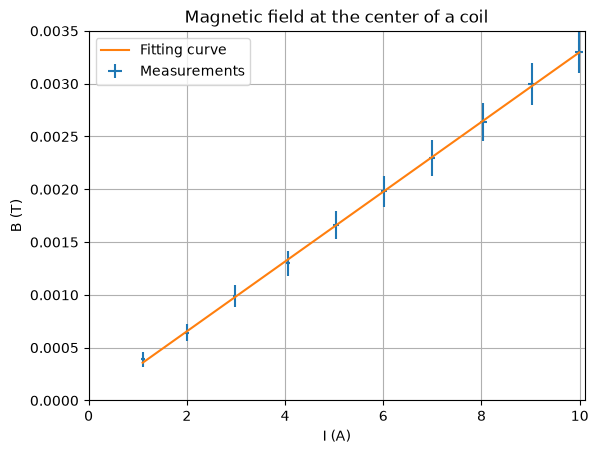

In [ ]:
# Fitting procedure without considering the errorbars but with help to guess the adjustable parameters.
def affine_function(x, a, b):
    return a * x + b


a_th = constant.mu_0 * N / np.sqrt(l ** 2 + D ** 2)  # Expected value for the slope.
popt, pcov = opt.curve_fit(affine_function, I, B, p0=np.array([a_th, 0.]))  # gives 0 as a first guess to around where should the value of a be located
a = popt[0]
b = popt[1]
print('a=', a, 'T/A,   a_th=', a_th, 'T/A')  # print to compare the expeceted value and the one we obtained, same for b
print('b=', b, 'T,   b_th=', 0, 'T')

plt.figure()
plt.errorbar(I, B, uB, uI, linestyle='', label='Measurements')
plt.plot(I, affine_function(I, a, b), label='Fitting curve')
plt.xlabel('I (A)')
plt.ylabel('B (T)')
plt.title('Magnetic field at the center of a coil')
plt.legend()
plt.axis([0, 10.1, 0, 3.5e-3])
plt.grid()
plt.show()

a=( 0.3278922062724227 +/- 0.01433054081325505 ) mT/A
a_th=( 0.35887237635885555 +/- 0.005031267517875478 ) mT/A
b=( 0.0068917695183918805 +/- 0.062486775309015405 ) mT
b_th= 0 T


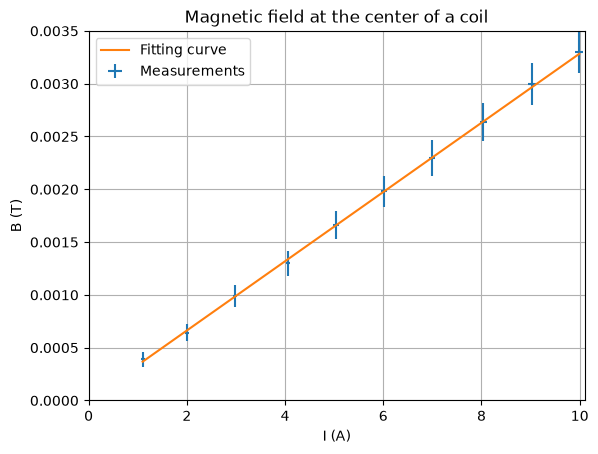

In [22]:
# Fitting procedure by considering the errorbars on the ordinates (here there are dominant so this is reasonable).
def affine_function(x, a, b):
    return a * x + b


popt, pcov = opt.curve_fit(affine_function, I, B, sigma=uB, p0=np.array([a_th, 0.]), absolute_sigma=True)  # giving both b0 and the error bar on B so that it knows which points are turstworthy
a = popt[0]
b = popt[1]
ua = np.sqrt(pcov[0, 0])  # COMMENT REQUIRED
ub = np.sqrt(pcov[1, 1])

ua_th = a_th * (uN / N + (l * ul + D * uD) / (l ** 2 + D ** 2))  # Uncertainty on the expected slope
# (obtained via propagation of uncertainties).
print('a=(', a * 1e3, '+/-', ua * 1e3, ') mT/A')
print('a_th=(', a_th * 1e3, '+/-', ua_th * 1e3, ') mT/A')  # COMMENT REQUIRED
print('b=(', b * 1e3, '+/-', ub * 1e3, ') mT')
print('b_th= 0 T')  # COMMENT REQUIRED

plt.figure()
plt.errorbar(I, B, uB, uI, linestyle='', label='Measurements')
plt.plot(I, affine_function(I, a, b), label='Fitting curve')
plt.xlabel('I (A)')
plt.ylabel('B (T)')
plt.title('Magnetic field at the center of a coil')
plt.legend()
plt.axis([0, 10.1, 0, 3.5e-3])
plt.grid()
plt.show()

<span style="color: #E43F6F; font-size: 22px;"><strong>V. Importing and exporting data</strong></span>

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>1) Importing data</i></span>

Experimental data or data obtained from a simulation are often obtained independently from the Python code you use to analyse your results. As a result, you should be able to import your data saved on your computer as a <tt>.txt</tt> or <tt>.csv</tt> file.

If your data are stored in a file as $N$ columns, all having $M$ lines, then NumPy has two functions which allow you to import your data easily: <tt>loadtxt</tt> or <tt>genfromtxt</tt>. In these lecture notes, we focus on the function <tt>genfromtxt</tt> which gives more flexibility. Look at the online documentation to understand how to use it: https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>2) Exporting data</i></span>

<span style="color: #1BBAC6; font-size: 16px; margin-left: 4em;"><i>a) Exporting tables of data</i></span>

To save arrays of data with $N$ columns, all having $M$ lines, the function <tt>savetxt</tt> of the package NumPy can be used. This function gives you flexibility, in particular to add comments, change the delimiter between data, etc.). For more details, consult the online documentation: https://numpy.org/doc/stable/reference/generated/numpy.savetxt.html

<span style="color: #1BBAC6; font-size: 16px; margin-left: 4em;"><i>b) Saving figures</i></span>

To save figures, you can use the function <tt>savefig</tt> of the module Pyplot of the package Matplotlib. Many options can be customized, and you can consult the online documentation for more details: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html

<span style="color: #E43F6F; font-size: 22px;"><strong>VI. Exercises</strong></span>

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>Exercise 1:</i></span>

We consider a random walker who takes steps of unit length along an axis. The walker starts at the origin $x = 0$ and the first step is chosen at random to the right or to the left with probability $1/2$ in each case. If the first step is to the right, the position after this first step is $x = +1$. The next step is then chosen, again with probability $1/2$ for each direction. This process is then repeated.

1) Draw the curve representing the position of the walker as a function of the number of steps. As we can consider that there is one step per unit of time, this is equivalent to plotting the position versus time.

2) Draw the curve which represents the square of the walker's distance from the origin as a function of time.

3) Now consider that there are 500 walkers. Plot on the same graph the curves which represent the square of the walkers distance from the origin as a function of time for all walkers. Represent also the curve which represents the average of the square of the distance of the walkers from the origin (called the Mean-Squared Displacement or MSD) as a function of time. You must plot the curves for all walkers in black and a small opacity, and the average in red.

4) The MSD $\Delta^2$ varies linearly with time $\Delta^2=2Dt$, with $D$ the diffusion coefficient of the walker. Perform a linear fit of the MSD and compare the estimated value of $D$ with the theoretical prediction $D=1/2$.

5) Plot the result of the fit and the MSD on a new graph. The graph must indicate the value of $D$ obtained from the fitting procedure, and also the Pearson correlation coefficient of the MSD and the number of steps (to confirm the linear dependency). If you do not remember the mathematical definition of the Pearson correlation coefficient, look on Wikipedia.

6) Save the result of the MSD and of the fit in a <tt>.txt</tt> file called <tt>MSD_Brownian.txt</tt>. The structure of the file is indicated below, the first line must explicitely indicate the content of each column, and the different columns must be separated by a 7 spaces:
#Number of steps     MSD     Linear fit

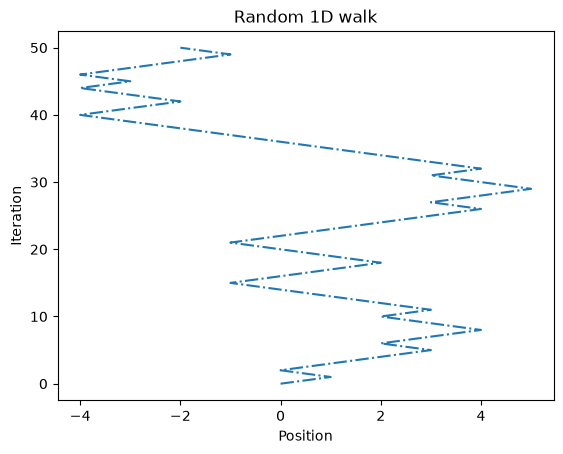

In [21]:
import numpy as np
import matplotlib.pyplot as plt

N = 50 # steps
n = np.arange(N+1)
pos = np.zeros_like(n)

for i in n[1:]:

    if np.random.random(1) > 0.5:
        pos[i] = pos[i-1] + 1
    else:
        pos[i] = pos[i-1] - 1

    
fig, ax = plt.subplots()

w = ax.plot(pos, n, "-.")
ax.set_xlabel("Position")
ax.set_ylabel("Iteration")
ax.set_title("Random 1D walk")


plt.show()
    

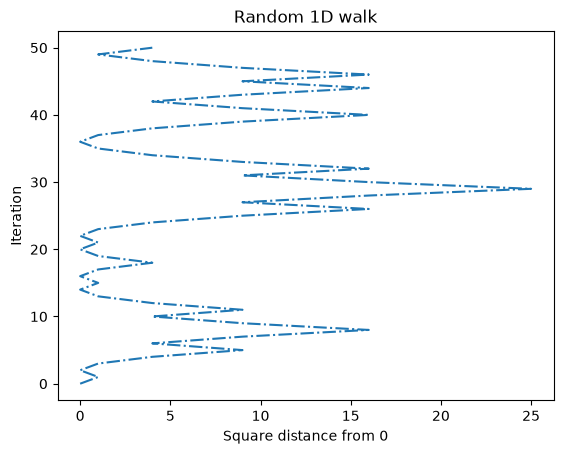

In [23]:
fig, ax = plt.subplots()

sw = ax.plot(pos**2, n, "-.")
ax.set_xlabel("Square distance from 0")
ax.set_ylabel("Iteration")
ax.set_title("Random 1D walk")


plt.show()

Text(0, 0.5, 'Squared distance to 0')

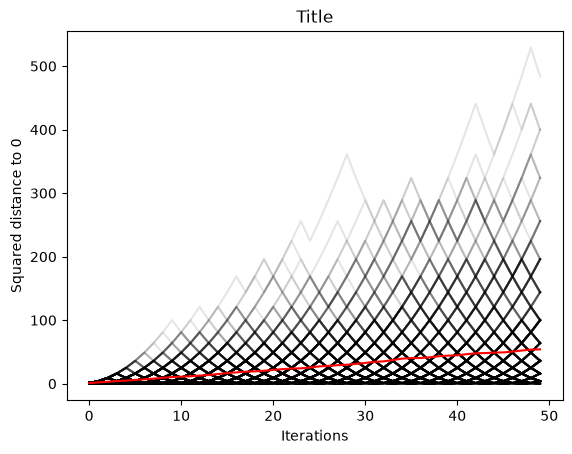

In [10]:
import numpy as np
import matplotlib.pyplot as plt


N = 50 # steps
a = 500 # amounts of Lucien

w = np.zeros((a, N))

for n in range(N):
    for i in range(a):

        if np.random.random(1) > 0.5:
            w[i,n] = w[i, n-1] + 1
        else:
            w[i,n] = w[i, n-1] - 1

fig, ax = plt.subplots()

reversed = (w**2).T
sqr_sum = np.mean(reversed, 1)

lucien = ax.plot(reversed, "-", color="black", alpha=0.1)
lucien_moyenne = ax.plot(sqr_sum, "-", color="red")



#lucien_moyenne = ax.plot(sqr_sum)

ax.set_title("Title")
ax.set_xlabel("Iterations")
ax.set_ylabel("Squared distance to 0")


D value from MSD : 0.5037227751150255 (Expected 0.5)


Text(0, 0.5, 'Squared distance to 0')

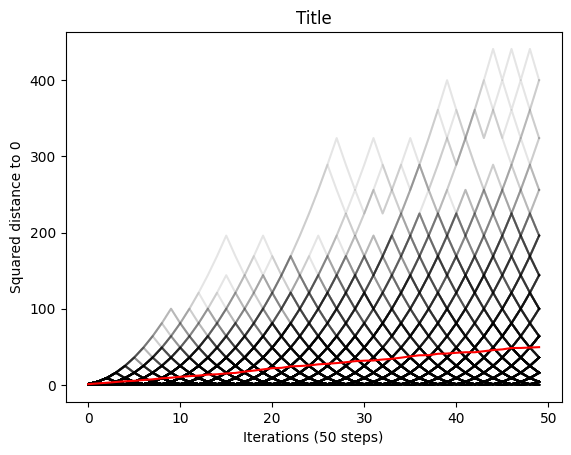

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp


N = 50 # steps
a = 500 # amounts of Lucien

w = np.zeros((a, N))

for n in range(N):
    for i in range(a):

        if np.random.random(1) > 0.5:
            w[i,n] = w[i, n-1] + 1
        else:
            w[i,n] = w[i, n-1] - 1

fig, ax = plt.subplots()

reversed = (w**2).T
sqr_sum = np.mean(reversed, 1)

lucien = ax.plot(reversed, "-", color="black", alpha=0.1)
lucien_moyenne = ax.plot(sqr_sum, "-", color="red")

result = sp.linregress(sqr_sum, np.linspace(0, N+1))

print(f"D value from MSD : {result.slope/2} (Expected 0.5)")

ax.set_title("Title")
ax.set_xlabel(f"Iterations ({N} steps)")
ax.set_ylabel("Squared distance to 0")


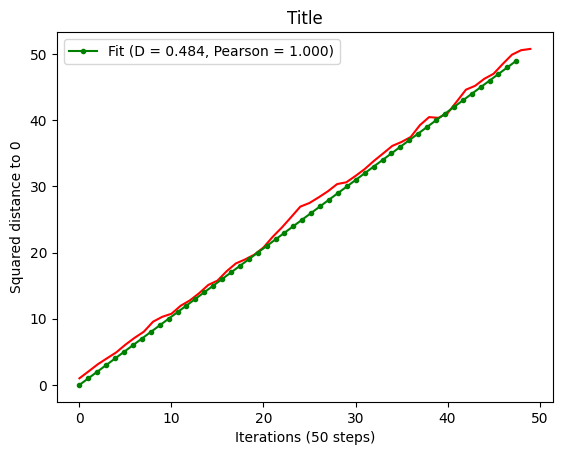

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp

def func(x, a):
    return a*x

N = 50 # steps
a = 500 # amounts of Lucien

w = np.zeros((a, N))

for n in range(N):
    for i in range(a):

        if np.random.random(1) > 0.5:
            w[i,n] = w[i, n-1] + 1
        else:
            w[i,n] = w[i, n-1] - 1

fig, ax = plt.subplots()

reversed = (w**2).T
sqr_sum = np.mean(reversed, 1)
result = sp.linregress(sqr_sum, np.arange(0, N, dtype=int))

lucien_moyenne = ax.plot(sqr_sum, "-", color="red")
lucien_regress = ax.plot(func(np.arange(0, N, dtype=int), result.slope), np.arange(0, N, dtype=int), ".-", color="green", label=f"Fit (D = {result.slope/2:.3f}, Pearson = {result.rvalue:.3f})")


ax.set_title("Title")
ax.set_xlabel(f"Iterations ({N} steps)")
ax.set_ylabel("Squared distance to 0")
ax.legend()

In [48]:
np.savetxt("MSD_Brownian.txt", np.array([np.arange(0, N, dtype=int), sqr_sum, func(np.arange(0, N, dtype=int), result.slope)]).T, delimiter='       ', header='# Number of Steps      MSD       Linear Fit')

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>Exercise 2:</i></span>

Write a program which performs the following tasks:

1) Open the file <tt>signal3.txt</tt> which contains the time series of a signal $s(t)$ (the first column gives the abscissae, the second column gives the ordinates).

2) Plot the signal $s(t)$.

3) Compute the DFT $\tilde{s}(f)$ of this signal.

4) Plot the power spectrum $\mathcal{S}(f)=\vert\tilde{s}(f)\vert^2$ of the signal. What should be done to eliminate the maximum at zero frequency?

5) Measure the three characteristic strictly positive frequencies of the signal. This question does not require any advanced function available in <tt>scipy.optimize</tt> or <tt>scipy.signal</tt>. What is the value of the spectrum for these frequencies?

6) Mark the locations of the characteristic frequencies on the plot of the spectrum and allow them to be distinguishable. Save the plot as a <tt>.pdf</tt> file.

In [140]:
import numpy as np
import matplotlib.pyplot as plt

unpack = np.genfromtxt("signal3.txt", skip_header=1, delimiter=',')
time, signal = unpack[:,0], unpack[:,1]



Text(0.5, 1.0, 's signal over time')

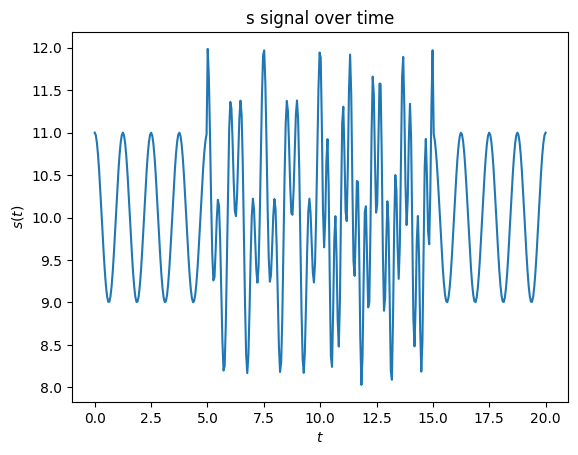

In [141]:
fig, ax = plt.subplots()

s = ax.plot(time, signal)
ax.set_ylabel(r"$s(t)$")
ax.set_xlabel(r"$t$")
ax.set_title("s signal over time")

In [142]:
tilde_s = np.fft.fft(signal)
tilde_s *= time[1] - time[0]
freq = np.fft.fftfreq(signal.size, time[1]-time[0])

Text(0.5, 1.0, 'Power spectrum of $S(t)$')

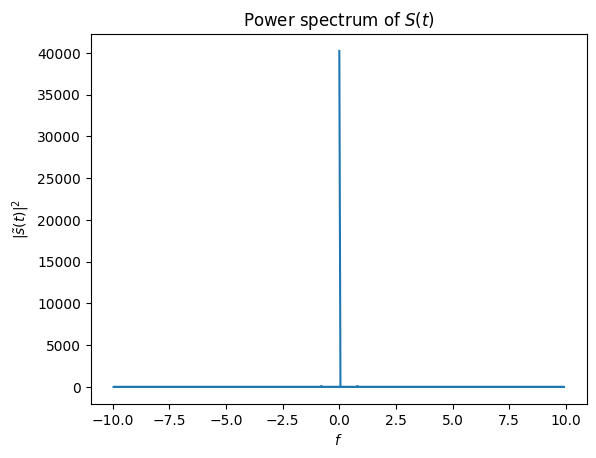

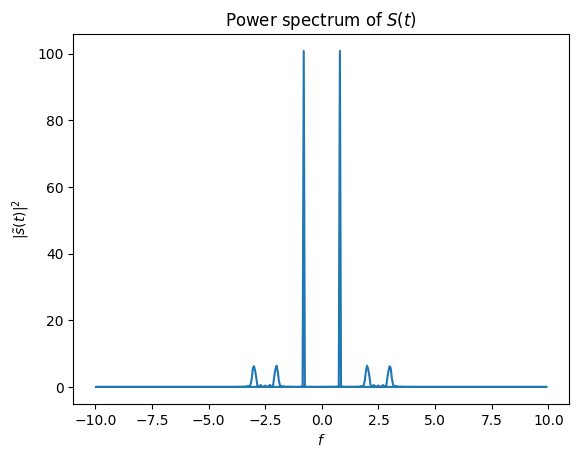

In [143]:
fig, ax = plt.subplots()

s = ax.plot(freq, np.abs(tilde_s)**2)
ax.set_ylabel(r"$|\tilde{s}(t)|^2$")
ax.set_xlabel(r"$f$")
ax.set_title(r"Power spectrum of $S(t)$")

signal -= np.mean(signal)  # We get rid of the mean that blows up big time in the frequency space at f = 0

tilde_s = np.fft.fft(signal)
tilde_s *= time[1] - time[0]
freq = np.fft.fftfreq(signal.size, time[1]-time[0])

fig, ax = plt.subplots()

s = ax.plot(freq, np.abs(tilde_s)**2)
ax.set_ylabel(r"$|\tilde{s}(t)|^2$")
ax.set_xlabel(r"$f$")
ax.set_title(r"Power spectrum of $S(t)$")


In [144]:
power = np.abs(tilde_s)**2
power = power[freq > 0]
freq_pos = freq[freq > 0]

mask = np.zeros_like(power, dtype=bool)

mask[(power >= np.sort(power)[-3:-2])] = True

char_power = power[mask]
char_freq = freq_pos[mask]

print(char_power, char_freq)

[100.80367289   6.35100247   6.20346266] [0.798  1.995  2.9925]


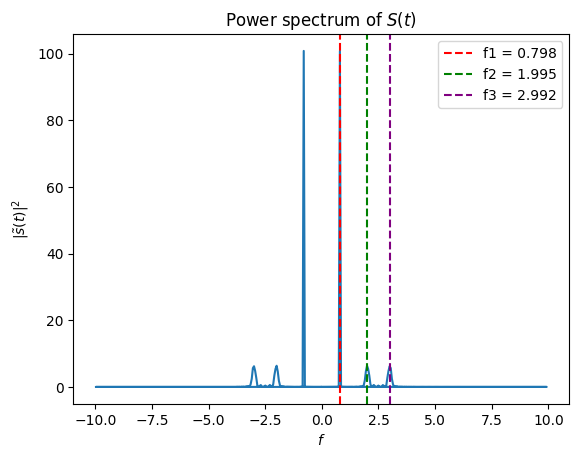

In [154]:
fig, ax = plt.subplots()

s = ax.plot(freq, np.abs(tilde_s)**2)
ax.axvline(char_freq[0], color='red', linestyle='--', label=f'f1 = {round(char_freq[0],3)}')
ax.axvline(char_freq[1], color='green', linestyle='--', label=f'f2 = {round(char_freq[1],3)}')
ax.axvline(char_freq[2], color='purple', linestyle='--', label=f'f3 = {round(char_freq[2],3)}')
ax.set_ylabel(r"$|\tilde{s}(t)|^2$")
ax.set_xlabel(r"$f$")
ax.set_title(r"Power spectrum of $S(t)$")
ax.legend()

fig.savefig('marvelous_plot.pdf')

<span style="color: #AB68B2; font-size: 18px; margin-left: 2em;"><i>Exercise 3:</i></span>

Write a program which performs the following tasks.

1) Generate $n=100\, 000$ independent samples of a random variable $X$ drawn from a Gaussian distribution of mean $\mu=3$ and standard deviation $\sigma=5$. Verify that the values of the mean and of the variance are close to their expectations.

2) Compute and plot the probability density function of $X$ (do not use the function <tt>matplotlib.pyplot.hist</tt>). Plot on the same graph the analytical prediction. We recall that the probability density function of a Gaussian random variable is given by
$$f(x)=\dfrac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\dfrac{(x-\mu)^2}{2\sigma^2}\right].$$

3) The cumulative distribution function (CDF) of a random variable is defined as $P(X\leq x) = \displaystyle \int_{-\infty}^{x}\mathrm{d}y\,f(y)$. Compute the CDF from the histogram.

4) Plot on the same graph the CDF computed from the histogram and its analytical expression. We recall that for a Gaussian distribution, the cumulative distribution function (CDF) reads $$P(X\leq x) = \dfrac{1}{2}\left[1+\mathrm{erf}\left(\dfrac{x-\mu}{\sqrt{2\sigma^2}}\right)\right],$$ where $\mathrm{erf}(x)=\displaystyle\frac{2}{\sqrt{\pi}}\int_0^x\mathrm{d}y\,e^{-y^2}$ is the error function.

In [31]:
import numpy as np
import matplotlib.pyplot as plt

n = 100000
mean = 3
std = 5

x = np.random.normal(mean, std, n)

print(f'mean : {np.mean(x)} (expected : {mean}), std : {np.std(x)} (expected : {std})')

mean : 2.974948771041599 (expected : 3), std : 4.989998032185793 (expected : 5)


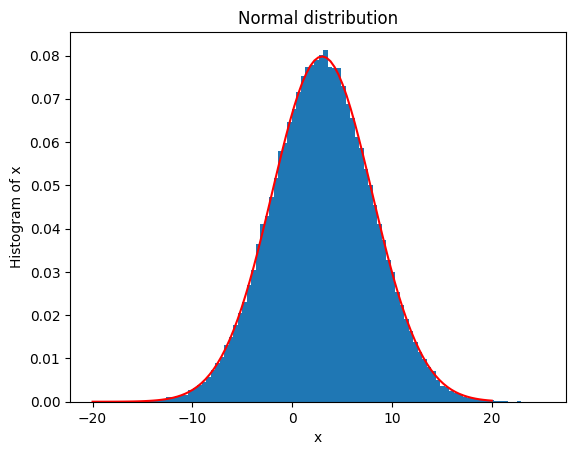

In [32]:

def th_density(x, m, s):
    return (1/np.sqrt(2*np.pi*s**2)) * np.exp((-(x-m)**2)/(2*s**2))

x_lin = np.linspace(-20, 20, 100)

histo, bin_edges = np.histogram(x, 100)
bin_width = bin_edges[1] - bin_edges[0]
histo_norm = histo/(len(x)*bin_width)
plt.figure()
plt.bar(bin_edges[:-1], histo_norm, bin_width, align='edge') 
plt.plot(x_lin, th_density(x_lin, mean, std), color='r')
plt.xlabel('x')
plt.ylabel('Histogram of x')
plt.title('Normal distribution')
plt.show()

In [33]:
sum = np.insert(np.cumsum(histo_norm)/np.sum(histo_norm), 0, 0)
print(sum)

[0.0000e+00 1.0000e-05 1.0000e-05 1.0000e-05 2.0000e-05 4.0000e-05
 9.0000e-05 1.0000e-04 1.3000e-04 1.9000e-04 2.0000e-04 2.2000e-04
 2.6000e-04 3.4000e-04 4.8000e-04 6.2000e-04 8.3000e-04 1.2700e-03
 1.7100e-03 2.2600e-03 3.0000e-03 3.7400e-03 4.9900e-03 6.4500e-03
 8.1800e-03 1.0250e-02 1.2820e-02 1.6080e-02 2.0090e-02 2.4700e-02
 3.0620e-02 3.7380e-02 4.5370e-02 5.4570e-02 6.4970e-02 7.7160e-02
 9.0850e-02 1.0724e-01 1.2576e-01 1.4508e-01 1.6640e-01 1.8965e-01
 2.1580e-01 2.4277e-01 2.7191e-01 3.0244e-01 3.3472e-01 3.6859e-01
 4.0346e-01 4.3852e-01 4.7411e-01 5.1022e-01 5.4687e-01 5.8173e-01
 6.1646e-01 6.5118e-01 6.8406e-01 7.1502e-01 7.4453e-01 7.7210e-01
 7.9853e-01 8.2274e-01 8.4533e-01 8.6578e-01 8.8431e-01 9.0111e-01
 9.1584e-01 9.2936e-01 9.4077e-01 9.5083e-01 9.5941e-01 9.6673e-01
 9.7293e-01 9.7815e-01 9.8258e-01 9.8620e-01 9.8935e-01 9.9163e-01
 9.9331e-01 9.9487e-01 9.9596e-01 9.9683e-01 9.9760e-01 9.9814e-01
 9.9857e-01 9.9892e-01 9.9918e-01 9.9939e-01 9.9956e-01 9.9970

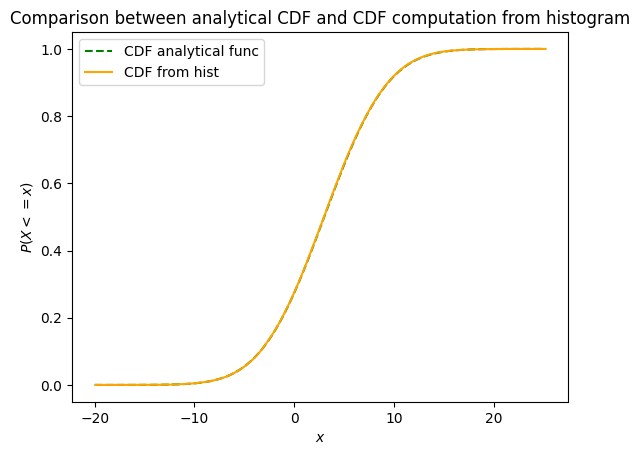

In [34]:
from scipy.special import erf

def p(x, m, s):
    return 0.5*(1+erf((x-m)/np.sqrt(2*s**2)))

x = np.linspace(-20, 25, 100)

fig, ax = plt.subplots()

th = ax.plot(x, p(x, mean, std), '--', color='green', label='CDF analytical func')
ap = ax.plot(bin_edges, sum, '-', color='orange', label='CDF from hist')

ax.set_ylabel(r"$P(X <= x)$")
ax.set_xlabel(r"$x$")
ax.set_title(r"Comparison between analytical CDF and CDF computation from histogram")
ax.legend()
